# Giai đoạn 8 — Bốn mốc đối chứng

```
┌───────────────────────────────────────────────────────────────┐
│                          08_MocChuan                          │
└───────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • 07_TachTrainTest/train.csv   —  11.880 dòng
    • 07_TachTrainTest/val.csv     —  2.546 dòng
         │
         ▼
  XỬ LÝ
    1. Mốc 1 — đoán lớp đông nhất
    2. Mốc 2 — đoán bừa trong nhóm người dùng đã chọn
    3. Mốc 3 — chỉ dùng 15 cột tổ hợp, bỏ hết 48 cột còn lại
    4. Mốc 4 — chỉ nguồn khảo sát, chưa nạp hồ sơ trúng tuyển  ⭐
    5. Mô hình đối chiếu — đủ 63 đặc trưng, đủ nguồn dữ liệu
    6. Chỉ số phân loại chuẩn: F1 · precision · recall · AUC
         │
         ▼
  ĐẦU RA
    • 08_MocChuan/moc_chuan.json
    • 08_MocChuan/bang_moc.csv
    • 08_MocChuan/chi_so_lop.csv
    • 08_MocChuan/hinh_8_*.png     —  2 hình
```

## Hướng 2 — khảo sát đã niêm phong

Bảng huấn luyện ở đây là `train_ttth.csv`, **16.296 dòng, 100% dẫn xuất từ hồ sơ trúng
tuyển**. Toàn bộ 676 phiếu khảo sát đã bị niêm phong ở Giai đoạn 6 và sẽ chỉ mở ở Giai
đoạn 10.

Nên mọi con số trong notebook này đo trên `val.csv` — vẫn là dòng TTTH. Chúng cho biết
mô hình khớp với phân phối nó được học đến đâu, **chưa** cho biết nó dự đoán học sinh
thật đến đâu. Câu hỏi thứ hai chỉ trả lời được ở Giai đoạn 10.

`sample_weight = 1.0` cho cả 16.296 dòng. Cột `nguon` và `rui_ro_vong_tron` nằm ngoài
tập đặc trưng — mô hình không nhìn thấy chúng và không có nhánh nào rẽ theo nguồn.

## Vì sao phải có mốc

Chín nhóm ngành có cỡ `[7, 6, 4, 4, 4, 4, 4, 3, 3]`. Nhóm 3 ngành thì **Top-3 tự đúng
100%** mà không cần mô hình nào. Một con số 90% đứng trơ trọi có thể chỉ hơn đoán bừa vài
điểm — hoặc thậm chí thua.

Đó cũng là lý do tầng tư vấn chỉ hiện **2 gợi ý**. Mọi bảng dưới đây đo tầng tư vấn ở
**Top-2** (`K_TU_VAN`), tầng khám phá ở **Top-3** — chỉ số Giai đoạn 9 dùng để chọn cấu hình.

Mọi bảng chỉ số trong báo cáo phải đọc cột **hơn bừa**, không đọc cột độ chính xác trần
trụi.

## Bốn mốc, mỗi mốc trả lời một câu hỏi khác nhau

| Mốc | Trả lời câu | Nếu mô hình không hơn thì |
|---|---|---|
| **1 — lớp đông nhất** | *"có hơn việc luôn gợi ý ngành hot không?"* | vô dụng hoàn toàn |
| **2 — bừa trong nhóm** | *"có hơn việc bốc đại trong nhóm không?"* | chế độ tư vấn vô nghĩa |
| **3 — chỉ tổ hợp** | *"48 đặc trưng kia có đóng góp gì không?"* | chỉ cần hỏi tổ hợp là đủ |
| **4 — bỏ 5 ngành vòng tròn** ⭐ | *"600 dòng bootstrap cho 5 ngành không có hồ sơ đóng góp gì?"* | nên bỏ hẳn 5 ngành đó |

## ⭐ Mốc 4 — phép thử riêng của Hướng 2

Hướng 1 dùng mốc 4 để hỏi *"nguồn khảo sát đóng góp bao nhiêu"*. Hướng 2 **không hỏi
được câu đó** — khảo sát đã niêm phong hết, bảng huấn luyện 100% từ TTTH.

Câu hỏi tương ứng ở đây liên quan tới 5 ngành không có hồ sơ trúng tuyển nào (Luật, Trí
tuệ nhân tạo, Quản lý Công nghiệp, Logistics, Du lịch). Dòng huấn luyện của chúng — 600
dòng bootstrap — được sinh từ chính 52 phiếu khảo sát sẽ bị niêm phong. Đó là **rò rỉ
vòng tròn**: dữ liệu huấn luyện đi ra từ tập kiểm định.

Mốc 4 bỏ hẳn 600 dòng đó rồi đo lại trên cùng tập val:

```
mô hình đầy đủ   (11.407 dòng, 39 ngành)             →  ?
mốc 4            (~11.000 dòng, 34 ngành có hồ sơ)   →  ?
```

Mô hình mốc 4 chỉ học được 34 ngành nên tự động trượt ở các dòng val thuộc 5 ngành kia.
Phần chênh cho biết mô hình đầy đủ phụ thuộc vào dữ liệu vòng tròn bao nhiêu — con số
này phải nêu kèm mỗi khi trình bày kết quả 39 ngành.

## Đo trên `val.csv`, không đụng `test_KHOA.csv`

Ba tập làm ba việc khác nhau:

| Tập | n | Việc của nó |
|---|--:|---|
| `train` | 11.880 | mô hình học. Con số ở đây **không phải đánh giá** — nó đo mức nhớ vẹt |
| `val` | 2.546 | **mọi quyết định thiết kế** diễn ra ở đây: chọn mốc, chọn siêu tham số |
| `test_KHOA` | 2.546 | niêm phong SHA-256, mở **đúng một lần** ở Giai đoạn 10 |

Tập nào dùng để quyết định thì tập đó thành lạc quan. Đó là lý do phải có tập thứ ba
chưa từng tham gia quyết định nào — nếu tinh chỉnh trên test thì con số cuối cùng đã bị
test tham gia vào thiết kế, và nó sẽ lạc quan hơn thực tế.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Điểm vận hành của sản phẩm: tầng tư vấn hiện K_TU_VAN gợi ý, tầng khám phá hiện
# K_KHAM_PHA. Nhóm nhỏ nhất có 3 ngành nên Top-3 tư vấn tự đúng 100% ở nhóm đó mà
# không cần mô hình — Top-2 là mức vẫn tách được mô hình khỏi mốc đoán bừa.
# Top-1/2/3/5 vẫn báo cáo đủ để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)
K_TU_VAN = 2
K_KHAM_PHA = 5

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_HocPhanPhoi",
    4: "04_SinhDacTrung",
    5: "05_KiemDinhDuLieuSinh",
    6: "06_NiemPhongKhaoSat",
    7: "07_TachTrainTest",
    8: "08_MocChuan",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def dat_nhan(ax, xs, ys, nhan, fs=9, mau=None):
    """Đặt nhãn cạnh từng điểm mà KHÔNG đè lên nhau.

    Viết thẳng chữ lên chấm thì các điểm sát nhau (cùng 0%, cùng cỡ dữ liệu) chồng
    chữ thành một mảng không đọc được. Hàm thử lần lượt các vị trí quanh điểm, lấy
    vị trí đầu tiên không chạm nhãn đã đặt; nhãn phải dời xa có đường dẫn về điểm.
    """
    from matplotlib.text import Text

    fig = ax.figure
    fig.canvas.draw()
    r = fig.canvas.get_renderer()
    vi_tri = [(5, 3), (5, -11), (-5, 3), (-5, -11)]
    for tang in range(1, 8):
        vi_tri += [(9, 3 + 11 * tang), (9, -11 - 11 * tang),
                   (-9, 3 + 11 * tang), (-9, -11 - 11 * tang)]
    da_dat = []

    def thu(x, y, t, dx, dy):
        a = ax.annotate(t, (x, y), xytext=(dx, dy), textcoords="offset points",
                        fontsize=fs, fontweight="bold", color=mau or C_DAM, zorder=6,
                        ha="left" if dx > 0 else "right", va="bottom",
                        arrowprops=(dict(arrowstyle="-", color="#8A949E", lw=.6,
                                         shrinkA=0, shrinkB=2) if abs(dy) > 12 else None))
        a.update_positions(r)
        return a, Text.get_window_extent(a, r)

    for x, y, t in zip(xs, ys, nhan):
        for dx, dy in vi_tri:
            a, hop = thu(x, y, t, dx, dy)
            if not any(hop.overlaps(h) for h in da_dat):
                break
            a.remove()
        else:
            a, hop = thu(x, y, t, *vi_tri[0])      # hết chỗ — đặt vị trí đầu
        da_dat.append(hop)


def hinh_theo_nganh(rd, cot, nhan_y, co_cham, sao=None, ghi_chu_sao=""):
    """Mỗi chấm một ngành: ngang là số dòng huấn luyện (log), dọc là độ chính xác.

    Ngành đáng chú ý (dưới 50% hoặc dưới 120 dòng) chỉ ghi SỐ cạnh chấm; tên đầy đủ
    nằm ở bảng bên phải. Không cắt cụt tên ngành, không để chữ đè lên nhau.
    """
    chu_y = (rd[(rd[cot] < .5) | (rd.n_hoc < 120)]
             .sort_values([cot, "n_hoc"]).head(22).reset_index(drop=True))
    cmap = plt.get_cmap("RdYlGn")
    fig = plt.figure(figsize=(16, 6.6))
    # wspace đủ rộng để nhãn thanh màu không chạm cột chấm màu của bảng bên phải
    gs = fig.add_gridspec(1, 2, width_ratios=[1.55, 1], wspace=0.24)
    ax, al = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

    sc = ax.scatter(rd.n_hoc, rd[cot] * 100, s=14 + rd.n_test * 1.6, c=rd[cot] * 100,
                    cmap=cmap, vmin=0, vmax=100, edgecolor="white", lw=.8, zorder=3)
    ax.set_xscale("log")
    ax.set_ylim(-10, 110)
    ax.set_xlabel("Số dòng huấn luyện của ngành (thang log)")
    ax.set_ylabel(nhan_y)
    fig.colorbar(sc, ax=ax, pad=0.012, fraction=0.035).set_label(nhan_y)
    dat_nhan(ax, chu_y.n_hoc.values, chu_y[cot].values * 100,
             [str(i + 1) for i in range(len(chu_y))])

    al.axis("off")
    al.set_xlim(0, 1)
    al.set_ylim(0, 1)
    al.text(0, 1.0, "Ngành được đánh số", fontsize=12, fontweight="bold", va="bottom")
    al.text(1, 1.0, "dòng huấn luyện · độ chính xác", fontsize=9, color="#5A6672",
            ha="right", va="bottom")
    buoc = min(0.93 / max(len(chu_y), 1), 0.07)
    for i, r in chu_y.iterrows():
        y = 0.96 - i * buoc
        al.scatter([0.012], [y - buoc * 0.32], s=46, color=cmap(r[cot]),
                   edgecolor="#8A949E", lw=.5, clip_on=False)
        al.text(0.075, y, str(i + 1), fontsize=10, fontweight="bold", ha="right", va="top")
        ten = r.ten + (" *" if sao and r[sao] else "")
        al.text(0.095, y, ten, fontsize=10, va="top")
        al.text(1, y, f"{int(r.n_hoc):,}".replace(",", ".") + f" · {r[cot] * 100:.0f}%",
                fontsize=9.5, ha="right", va="top", color="#5A6672")
    chu = f"Cỡ chấm: {co_cham}."
    if sao:
        chu += f"   * {ghi_chu_sao}."
    al.text(0, 0.96 - len(chu_y) * buoc - 0.02, chu, fontsize=9, color="#5A6672", va="top")
    return fig, ax, al


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

def nap(co_test=False, co_ttth=True, co_fold=False):
    """Đọc mọi thứ notebook huấn luyện cần.

    ⚠️ HƯỚNG 2 — khác Hướng 1 ở chỗ căn bản: 676 phiếu khảo sát KHÔNG bao giờ
    vào tập huấn luyện. Giai đoạn 6 niêm phong toàn bộ chúng làm tập kiểm định
    người thật độc lập; chia train/val/test chỉ diễn ra trên phần TTTH.

        Giai đoạn 3–5   d["train"] = TOÀN BỘ 676 phiếu — chỉ để BỘ SINH học
                                     phân phối, không phải để XGBoost học
        Giai đoạn 8–9   co_fold=True  → đọc train.csv và cv_folds.json của GĐ 7
        Giai đoạn 10    co_test=True  → mở CẢ HAI tập kiểm định ĐÚNG MỘT LẦN:
                                     test TTTH và 676 phiếu khảo sát niêm phong

    Khoá "nhom" đọc từ `nganh_to_nhom` trong mapping.json — nguồn chuẩn duy nhất.
    """
    m = json.loads((thu_muc(1) / "mapping.json").read_text(encoding="utf-8"))
    d = {
        "likert": m["cot_likert"],
        "diem": m["cot_diem"],
        "ma_to_ten": {int(k): v for k, v in m["ma_to_ten"].items()},
        "nhom": {int(k): v for k, v in m["nganh_to_nhom"].items()},
        "ten_nhom": {int(k): v for k, v in m["ten_nhom"].items()},
        "ten_cach_nhom": m.get("ten_cach_nhom", "nhóm ngành"),
        "train": pd.read_csv(thu_muc(1) / "khaosat_sach.csv"),
    }
    d["ttth"] = pd.read_csv(thu_muc(2) / "ttth_sach.csv") if co_ttth else pd.DataFrame()
    if co_fold:
        d["train"] = pd.read_csv(thu_muc(7) / "train.csv")
        d["folds"] = json.loads((thu_muc(7) / "cv_folds.json").read_text(encoding="utf-8"))
    if co_test:
        d["test"] = pd.read_csv(thu_muc(7) / "test_KHOA.csv")
        # Tập kiểm định NGƯỜI THẬT — niêm phong từ Giai đoạn 6, mở cùng lúc.
        d["khaosat_niemphong"] = pd.read_csv(thu_muc(6) / "khaosat_NIEMPHONG.csv")

    nguon = [d["train"].to_hop_thi.str.split(" ").str[0]]
    if co_ttth:
        nguon.append(d["ttth"].to_hop_thi.astype(str))
    d["to_hop"] = sorted(set().union(*[set(s) for s in nguon]))
    d["nganh"] = np.sort(d["train"].ma_nganh.unique())
    d["i_nganh"] = {m_: i for i, m_ in enumerate(d["nganh"])}

    # Thống kê điểm để quy z-score. Tính trên TRAIN (+ TTTH nếu dùng), tuyệt đối
    # không đụng test — nếu không thì thông tin test rò rỉ qua bước chuẩn hoá.
    goc = [d["train"][d["diem"]]] + ([d["ttth"][d["diem"]]] if co_ttth else [])
    g = pd.concat(goc).astype(float)
    d["diem_mu"] = g.mean().values
    d["diem_sd"] = g.std().replace(0, 1).values
    return d


def dac_trung(df, D, co_khao_sat=True):
    """Ma trận 63 đặc trưng — MỘT định nghĩa duy nhất cho cả hai nguồn dữ liệu.

    `co_khao_sat=False` dùng cho hồ sơ trúng tuyển: nguồn này chỉ có điểm thi và
    tổ hợp. Cột thiếu để NaN chứ không điền bừa — XGBoost học luôn hướng rẽ cho
    giá trị thiếu ngay trong thuật toán, còn điền bừa tạo ra giá trị không có thật.
    """
    n = len(df)
    L, C_DIEM = D["likert"], D["diem"]
    th = df["to_hop_thi"].astype(str).str.split(" ").str[0].values
    Dm = df[C_DIEM].astype(float).values
    Lk = df[L].astype(float).values if co_khao_sat else np.full((n, len(L)), np.nan)

    ph = [pd.DataFrame(Lk, columns=L)]

    # Likert chuẩn hoá theo từng người: người hay chọn 4-5 và người hay chọn 2-3
    # cùng "thích logic nhất" nhưng để thô thì mô hình đọc thành hai hồ sơ khác
    # hẳn. Trừ trung bình của chính người đó thì còn lại sở thích TƯƠNG ĐỐI.
    with np.errstate(invalid="ignore"):
        mu = np.nanmean(Lk, 1, keepdims=True)
        sd = np.nanstd(Lk, 1, keepdims=True)
    sd = np.where((sd == 0) | np.isnan(sd), 1.0, sd)
    ph.append(pd.DataFrame(Lk - mu, columns=[f"ips_{c}" for c in L]))
    ph.append(pd.DataFrame({"likert_tb": mu[:, 0], "likert_dolech": sd[:, 0]}))

    ph.append(pd.DataFrame(Dm, columns=C_DIEM))
    # 8.0 môn Toán và 8.0 môn Văn không cùng ý nghĩa — quy z-score mới so được
    z = (Dm - D["diem_mu"]) / D["diem_sd"]
    ph.append(pd.DataFrame(z, columns=[f"z_{c}" for c in C_DIEM]))
    with np.errstate(invalid="ignore", divide="ignore"):
        ph.append(pd.DataFrame({
            "diem_tb": np.nanmean(Dm, 1),
            "diem_lech": np.nanmax(Dm, 1) - np.nanmin(Dm, 1),
            "z_tb": np.nanmean(z, 1),
            "z_max": np.nanmax(z, 1),
        }))

    # Tổ hợp là dữ liệu phân loại, KHÔNG có thứ tự. Mã hoá thành số (A00=0,
    # A01=1…) sẽ dạy mô hình rằng D01 "lớn hơn" A00 và trung bình A00 với B00 ra
    # A01 — vô nghĩa. One-hot tránh được: mỗi cột chỉ hỏi "có thi tổ hợp này không".
    ph.append(pd.DataFrame({f"th_{t}": (th == t).astype(float) for t in D["to_hop"]}))
    gt = ((df["gioi_tinh"] == "Nam").astype(float).values if "gioi_tinh" in df
          else np.full(n, np.nan))
    mt = (df["muc_tieu_ma"].astype(float).values if "muc_tieu_ma" in df
          else np.full(n, np.nan))
    ph.append(pd.DataFrame({"gioi_tinh_nam": gt, "muc_tieu": mt}))
    return pd.concat([p.reset_index(drop=True) for p in ph], axis=1)


def nhom_dac_trung(cols, D):
    """Gom tên cột thành 8 nhóm — dùng khi in bảng thống kê và vẽ hình."""
    L, C_DIEM = D["likert"], D["diem"]
    return {
        "Likert thô": [c for c in cols if c in L],
        "Likert chuẩn hoá theo người": [c for c in cols if c.startswith("ips_")],
        "Thống kê Likert": [c for c in cols if c in ("likert_tb", "likert_dolech")],
        "Điểm thi thô": [c for c in cols if c in C_DIEM],
        "Điểm z-score từng môn": [c for c in cols if c.startswith("z_diem_")],
        "Phái sinh từ điểm": [c for c in cols
                              if c in ("diem_tb", "diem_lech", "z_tb", "z_max")],
        "Tổ hợp xét tuyển (one-hot)": [c for c in cols if c.startswith("th_")],
        "Nhân khẩu học & mục tiêu": [c for c in cols
                                     if c in ("gioi_tinh_nam", "muc_tieu")],
    }

from xgboost import XGBClassifier


def mo_hinh(**kw):
    """XGBoost phân loại. KHÔNG ép `objective` — với nhóm 2 ngành XGBoost tự
    dùng binary:logistic (không có num_class), ép multi:softprob sẽ lỗi."""
    return XGBClassifier(**{**dict(
        max_depth=5, n_estimators=400, learning_rate=0.06, min_child_weight=3,
        subsample=0.8, colsample_bytree=0.6, reg_lambda=5.0,
        tree_method="hist", n_jobs=-1, verbosity=0, random_state=SEED), **kw})


class MoHinhNganh:
    """Mô hình gợi ý ngành. Chỉ dùng XGBoost phân loại — không có gì khác.

    Cách hoạt động, một câu:
        mô hình cho ra XÁC SUẤT cho từng ngành → bỏ những ngành không thuộc
        nhóm người dùng chọn → lấy k ngành xác suất cao nhất còn lại.

    Hai chế độ, đúng cách web gọi API:
        fieldId = None  → xếp hạng cả 39 ngành          (chế độ khám phá)
        fieldId = k     → chỉ xếp hạng ngành trong nhóm k (chế độ tư vấn)

    `rieng_nhom=True` → mỗi nhóm một mô hình nhỏ, chỉ học các ngành của nhóm đó.
    Mô hình chung phải trải sức phân biệt mọi cặp ngành, kể cả cặp ở hai nhóm
    khác hẳn nhau mà thực tế không bao giờ phải so; mô hình riêng chỉ học đúng
    việc phân biệt vài ngành trong một nhóm.
    """

    def __init__(self, D, hp=None, rieng_nhom=False, hp_nhom=None,
                 phan_tang=None):
        """`phan_tang` — dict {mã nhóm: {mã ngành: id lĩnh vực con}}.

        Với nhóm nhiều ngành, học MỘT LƯỢT 10 lớp bắt mô hình vẽ đồng thời 45
        đường ranh giới, kể cả những cặp gần như không tách được. Học hai bước
        thì bước 1 chỉ phải tách vài lĩnh vực con — việc dễ hơn và có tín hiệu
        thật — rồi bước 2 mới đi vào chỗ khó:

            P(ngành) = P(lĩnh vực con) × P(ngành | lĩnh vực con)

        Mô hình TỰ đoán lĩnh vực con, người dùng không cung cấp gì thêm, nên mốc
        đoán bừa không đổi. Đo trên khối Kinh doanh (10 ngành): 44.5% → 49.3%.
        """
        self.D = D
        self.hp = hp or {}
        self.rieng_nhom = rieng_nhom
        self.hp_nhom = hp_nhom or {}
        self.phan_tang = phan_tang or {}
        self.trong = {g: [n for n in D["nganh"] if D["nhom"][n] == g]
                      for g in sorted(set(D["nhom"].values()))}

    @staticmethod
    def _fit1(X, y, hp, w=None):
        """XGBoost 3.x bắt buộc mã lớp liền mạch 0..n-1, mà lô nhỏ có thể vắng
        vài ngành — nên phải đánh số lại rồi ánh xạ ngược lúc dự đoán."""
        co = np.unique(y)
        m = mo_hinh(**hp).fit(X, np.searchsorted(co, y), sample_weight=w)
        return m, co

    def fit(self, X, y, w=None):
        X, y = np.asarray(X), np.asarray(y)
        self.m, self.co = self._fit1(X, y, self.hp, w)
        self.m_tang = {}
        if self.rieng_nhom:
            self.m_nhom = {}
            for g, ds in self.trong.items():
                sel = np.isin(y, ds)
                if len(ds) < 2 or sel.sum() < 5 or len(np.unique(y[sel])) < 2:
                    continue
                hp_g = self.hp_nhom.get(g, self.hp)
                w_g = None if w is None else w[sel]
                self.m_nhom[g] = self._fit1(X[sel], y[sel], hp_g, w_g)
                if g in self.phan_tang:
                    self.m_tang[g] = self._fit_tang(
                        X[sel], y[sel], w_g, self.phan_tang[g], hp_g)
        return self

    def _fit_tang(self, X, y, w, ban_do, hp):
        """Hai bước: đoán lĩnh vực con trước, rồi đoán ngành trong lĩnh vực đó."""
        s = np.array([ban_do[v] for v in y])
        co_s = np.unique(s)
        if len(co_s) < 2:
            return None
        m_sub = mo_hinh(**hp).fit(X, np.searchsorted(co_s, s), sample_weight=w)
        con = {}
        for k, sv in enumerate(co_s):
            m_ = s == sv
            if len(np.unique(y[m_])) < 2:
                con[k] = (None, np.unique(y[m_]))
                continue
            con[k] = self._fit1(X[m_], y[m_], hp, None if w is None else w[m_])
        return m_sub, co_s, con

    def _rai(self, pr, co, n_dong):
        """Trải xác suất của model (chỉ vài lớp) ra đủ 39 cột ngành."""
        S = np.zeros((n_dong, len(self.D["nganh"])))
        for c, ma in enumerate(co):
            S[:, self.D["i_nganh"][ma]] = pr[:, c]
        return S

    def _diem_tang(self, X, bo):
        """P(ngành) = P(lĩnh vực con) × P(ngành | lĩnh vực con)."""
        m_sub, co_s, con = bo
        p_sub = m_sub.predict_proba(X)
        S = np.zeros((len(X), len(self.D["nganh"])))
        for k in range(len(co_s)):
            m, co = con[k]
            if m is None:
                for ma in co:
                    S[:, self.D["i_nganh"][ma]] = p_sub[:, k]
                continue
            pr = m.predict_proba(X)
            for c, ma in enumerate(co):
                S[:, self.D["i_nganh"][ma]] = p_sub[:, k] * pr[:, c]
        return S

    def diem(self, X, nhom_biet=None):
        """Xác suất trên 39 ngành. `nhom_biet` = mã nhóm người dùng chọn."""
        X = np.asarray(X)
        S = self._rai(self.m.predict_proba(X), self.co, len(X))
        if nhom_biet is None:
            return S
        nhom_biet = np.asarray(nhom_biet)
        if self.rieng_nhom:
            for g, (m, co) in self.m_nhom.items():
                sel = nhom_biet == g
                if not sel.any():
                    continue
                if self.m_tang.get(g) is not None:
                    S[sel] = self._diem_tang(X[sel], self.m_tang[g])
                else:
                    S[sel] = self._rai(m.predict_proba(X[sel]), co, int(sel.sum()))
        # Bỏ mọi ngành ngoài nhóm người dùng đã chọn
        mat_na = np.zeros_like(S)
        for i, g in enumerate(nhom_biet):
            for n in self.trong[int(g)]:
                mat_na[i, self.D["i_nganh"][n]] = 1.0
        return S * mat_na


def top_k(S, y, NG, ks=TOP_K):
    o = np.argsort(-S, axis=1)
    return {k: float(np.mean([y[i] in NG[o[i, :k]] for i in range(len(y))])) for k in ks}


def bua_toan_bo(n_lop, ks=TOP_K):
    """Đoán bừa k ngành trong toàn bộ danh mục."""
    return {k: min(k, n_lop) / n_lop for k in ks}


def bua_trong_nhom(y, nhom, ks=TOP_K):
    """Đoán bừa k ngành TRONG nhóm đúng.

    Bắt buộc báo cáo kèm: nhóm chỉ có 2 ngành thì Top-3 tự đúng 100% mà không cần
    mô hình nào. Thiếu cột này, một con số 85% có thể chỉ hơn đoán bừa vài điểm mà
    người đọc vẫn tưởng mô hình giỏi.
    """
    co = pd.Series(list(nhom.values())).value_counts()
    return {k: float(np.mean([min(k, co[nhom[m]]) / co[nhom[m]] for m in y])) for k in ks}


def ky_nang(acc, bua):
    """Phần lỗi của đoán bừa mà mô hình XOÁ ĐƯỢC.

        kỹ năng = (acc − bừa) / (1 − bừa)

    Vì sao cần chỉ số này: chia nhóm càng nhỏ thì đoán bừa càng cao, nên con số
    độ chính xác trần trụi KHÔNG so được giữa các cách chia nhóm khác nhau.
    Kỹ năng đã trừ sạch lợi thế đó — 0% là chỉ ngang đoán bừa, 100% là hoàn hảo.

    Ví dụ: 7 khối đạt 69.7% với bừa 49.2% → kỹ năng 40.3%.
           10 nhóm đạt 87.8% với bừa 75.9% → kỹ năng 49.3%.
    Con số thứ hai cao hơn thật, nhưng không cao như 87.8% so với 69.7% gợi ý.
    """
    return (acc - bua) / (1 - bua) if bua < 1 else float("nan")


def bua_pho_bien(y_hoc, y_do, nhom, ks=TOP_K):
    """Mốc đối chứng THỰC TẾ: luôn gợi ý k ngành ĐÔNG SINH VIÊN NHẤT trong nhóm.

    Đây là quy tắc mà bất kỳ ai cũng làm được bằng vài dòng code, KHÔNG cần khảo
    sát, KHÔNG cần điểm thi, KHÔNG cần mô hình. Tần suất học từ `y_hoc` (tập
    train), rồi áp lên `y_do`.

    VÌ SAO CẦN: mốc "đoán bừa" (chọn ngẫu nhiên trong nhóm) quá dễ vượt và không
    ai xây hệ thống như vậy. Phân bố ngành trong nhóm thường lệch mạnh, nên chỉ
    riêng việc gợi ý ngành phổ biến đã đúng khá nhiều. Một mô hình học máy chỉ
    thực sự có giá trị khi vượt được mốc NÀY.
    """
    y_hoc, y_do = np.asarray(y_hoc), np.asarray(y_do)
    g_hoc = np.array([nhom[m] for m in y_hoc])
    g_do = np.array([nhom[m] for m in y_do])
    out = {}
    for k in ks:
        top = {g: set(pd.Series(y_hoc[g_hoc == g]).value_counts().head(k).index)
               for g in np.unique(g_hoc)}
        out[k] = float(np.mean([y_do[i] in top.get(g_do[i], set())
                                for i in range(len(y_do))]))
    return out


def ky_nang_vs(acc, moc):
    """Phần lỗi của MỘT MỐC BẤT KỲ mà mô hình xoá được."""
    return (acc - moc) / (1 - moc) if moc < 1 else float("nan")


def chi_so_lop(S, y, NG, co_auc=True):
    """Các chỉ số phân loại chuẩn, bổ sung cho Top-k.

    Vì sao cần: độ chính xác trên 39 ngành mất cân bằng bị ngành đông chi phối.
    Mốc "luôn đoán ngành đông nhất trong nhóm" đã đạt 88,5% ở chế độ tư vấn mà
    không dùng mô hình nào. **macro-F1** cho mỗi ngành trọng số bằng nhau nên nó
    phơi ra chuyện mô hình bỏ rơi ngành ít hồ sơ; **weighted-F1** giữ trọng số
    theo cỡ ngành, luôn cao hơn — chênh lệch giữa hai con số chính là mức độ
    thiên vị ngành đông.

    ⚠️ `auc_ovr` ở đây là AUC ĐÁNH GIÁ PHÂN LOẠI (một-đối-phần-còn-lại, càng
    gần 1 càng tốt). KHÔNG phải AUC ở Giai đoạn 5 — con số đó đo bộ phân biệt
    thật/giả và **0,50 mới là lý tưởng**. Hai chỉ số trùng tên, ngược chiều
    nhau; báo cáo phải gọi rõ tên từng cái.

    Chỉ tính AUC khi `S` là phân phối xác suất đầy đủ trên 39 ngành. Ở chế độ
    tư vấn, `S` đã bị che bớt ngành ngoài nhóm nên hàng không còn tổng bằng 1 —
    truyền `co_auc=False`.
    """
    from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

    y = np.asarray(y)
    du = np.asarray(NG)[np.argmax(S, axis=1)]          # dự đoán Top-1
    ra = {
        "acc_top1": float(np.mean(du == y)),
        "f1_macro": float(f1_score(y, du, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y, du, average="weighted", zero_division=0)),
        "precision_macro": float(precision_score(y, du, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y, du, average="macro", zero_division=0)),
        "auc_ovr": float("nan"),
    }
    if co_auc:
        # roc_auc_score đòi mọi lớp trong `labels` phải xuất hiện ở y_true; ngành
        # vắng mặt trong lát cắt đang đo thì bỏ khỏi phép tính chứ không bỏ cả AUC.
        co = np.isin(np.asarray(NG), np.unique(y))
        if co.sum() >= 2:
            P = S[:, co]
            t = P.sum(axis=1, keepdims=True)
            P = np.divide(P, t, out=np.full_like(P, 1 / co.sum()), where=t > 0)
            try:
                ra["auc_ovr"] = float(roc_auc_score(
                    y, P, multi_class="ovr", average="macro",
                    labels=np.asarray(NG)[co]))
            except ValueError:
                pass
    return ra


def hang_cua_nganh_dung(S, y, NG):
    """Thứ hạng (đếm từ 1) của ngành đúng trong danh sách mô hình xếp ra."""
    o = np.argsort(-np.asarray(S), axis=1)
    NG = np.asarray(NG)
    y = np.asarray(y)
    return np.array([int(np.where(NG[o[i]] == y[i])[0][0]) + 1 for i in range(len(y))])


def chi_so_xep_hang(S, y, NG, k):
    """Chỉ số đánh giá đúng cho hệ thống trả về k gợi ý.

    Vì sao không dùng F1/precision/recall: chúng giả định hệ thống trả về MỘT
    nhãn. Hệ thống này trả 2 gợi ý ở chế độ tư vấn và 5 ở chế độ khám phá, nên
    nhóm chỉ số Top-1 đo tại một điểm vận hành không tồn tại trong sản phẩm.

    ⚠️ KHÔNG báo cáo precision@k và recall@k. Mỗi em chỉ có ĐÚNG MỘT ngành đúng,
    nên:
        recall@k    = hit@k        (trùng khít, không phải chỉ số mới)
        precision@k = hit@k / k    (chia cứng cho k, không mang thêm thông tin)
    Đưa vào bảng chỉ làm con số trông tệ đi mà không nói thêm được gì.

    Các chỉ số trả về:
        hit_k        — tỉ lệ ngành đúng nằm trong k gợi ý. Chính là Top-k.
        macro_hit_k  — trung bình hit@k TỪNG NGÀNH rồi mới lấy trung bình. Đây là
                       bản Top-k của macro-F1: mỗi ngành trọng số bằng nhau, nên
                       nó phơi ra chuyện mô hình bỏ rơi ngành ít hồ sơ, nhưng hỏi
                       tại ĐÚNG điểm vận hành thay vì hỏi ở Top-1.
        mrr          — trung bình 1/thứ hạng. Giữ được thông tin về THỨ TỰ mà
                       hit@k làm mờ đi: xếp đúng ở hạng 1 khác hẳn hạng 3.
        ndcg_k       — chấm theo vị trí, cắt ở k. Hạng 1 trọn điểm, hạng 2 được
                       1/log₂3 ≈ 0,63, ra ngoài k thì 0. Đây là chỉ số tương ứng
                       khi cần "AUC có cắt ở k" — AUC thật không có ngưỡng cắt
                       nên không tồn tại khái niệm AUC@k.
    """
    r = hang_cua_nganh_dung(S, y, NG)
    trung = r <= k
    per = pd.DataFrame({"y": np.asarray(y), "t": trung}).groupby("y").t.mean()
    return {
        "k": int(k),
        "hit_k": float(trung.mean()),
        "macro_hit_k": float(per.mean()),
        "mrr": float(np.mean(1.0 / r)),
        "ndcg_k": float(np.mean(np.where(trung, 1.0 / np.log2(r + 1), 0.0))),
        "hang_trung_vi": float(np.median(r)),
        "hang_trung_binh": float(r.mean()),
        "n_nganh_duoi_50": int((per < 0.5).sum()),
        "n_nganh": int(len(per)),
    }


def mrr_doan_bua(y, nhom=None, n_lop=None):
    """MRR của việc bốc ngẫu nhiên — mốc để so với MRR của mô hình.

    Bốc ngẫu nhiên trong m lựa chọn thì kỳ vọng 1/hạng là trung bình điều hoà
    (1/1 + 1/2 + … + 1/m) / m. Truyền `nhom` cho chế độ tư vấn (m = cỡ nhóm),
    `n_lop` cho chế độ khám phá (m = 39).
    """
    if n_lop is not None:
        return float(np.mean(1.0 / np.arange(1, n_lop + 1)))
    co = pd.Series(list(nhom.values())).value_counts()
    return float(np.mean([np.mean(1.0 / np.arange(1, co[nhom[m]] + 1)) for m in y]))


def in_chi_so_xep_hang(hang):
    """`hang` = [(tên tầng, dict từ chi_so_xep_hang, mrr đoán bừa), …]"""
    print("═" * 104)
    print(f"{'Tầng':<24}{'k':>4}{'Hit@k':>10}{'macro Hit@k':>14}{'MRR':>9}"
          f"{'MRR bừa':>10}{'NDCG@k':>10}{'hạng t.vị':>11}{'ngành <50%':>12}")
    print("─" * 104)
    for ten, d, mb in hang:
        print(f"{ten:<24}{d['k']:>4}{d['hit_k']:>9.1%}{d['macro_hit_k']:>14.1%}"
              f"{d['mrr']:>9.3f}{mb:>10.3f}{d['ndcg_k']:>10.3f}"
              f"{d['hang_trung_vi']:>11.0f}"
              f"{str(d['n_nganh_duoi_50'])+'/'+str(d['n_nganh']):>12}")
    print("═" * 104)
    print("Hit@k = Top-k · macro Hit@k = bản Top-k của macro-F1 (mỗi ngành ngang nhau)")
    print("MRR giữ thông tin THỨ TỰ mà Hit@k làm mờ · NDCG@k chấm theo vị trí, cắt ở k")
    print("KHÔNG báo cáo precision@k (= hit@k/k) và recall@k (= hit@k) — trùng lặp")


def in_chi_so_lop(hang):
    """In bảng F1 / AUC. `hang` = [(tên lát cắt, dict từ chi_so_lop, n), …]"""
    print("═" * 100)
    print(f"{'Lát cắt':<30}{'n':>8}{'Top-1':>9}{'F1 macro':>11}{'F1 w.':>9}"
          f"{'P macro':>10}{'R macro':>10}{'AUC OvR':>10}")
    print("─" * 100)
    for ten, d, n in hang:
        a = "—" if np.isnan(d["auc_ovr"]) else f"{d['auc_ovr']:.3f}"
        print(f"{ten:<30}{n:>8,}{d['acc_top1']:>9.1%}{d['f1_macro']:>11.3f}"
              f"{d['f1_weighted']:>9.3f}{d['precision_macro']:>10.3f}"
              f"{d['recall_macro']:>10.3f}{a:>10}")
    print("═" * 100)
    print("macro = mỗi ngành trọng số bằng nhau · weighted = theo cỡ ngành")
    print("chênh macro↔weighted càng lớn, mô hình càng thiên vị ngành đông")
    print("AUC OvR: càng gần 1 càng tốt — KHÁC AUC Giai đoạn 5 (0,50 là lý tưởng)")


def dong(ten, do_duoc, mocbua, ks=TOP_K):
    r = {"cau_hinh": ten}
    for k in ks:
        r[f"top{k}"], r[f"bua{k}"] = do_duoc[k], mocbua[k]
        r[f"hon{k}"] = do_duoc[k] - mocbua[k]
        r[f"kn{k}"] = ky_nang(do_duoc[k], mocbua[k])
    return r


def in_bang(rows, tieu_de="", ks=TOP_K):
    w = max([len(r["cau_hinh"]) for r in rows] + [20]) + 2
    tong = w + 35 * len(ks)
    if tieu_de:
        print("═" * tong); print(tieu_de)
    print("═" * tong)
    print(f"{'Cấu hình':{w}s}" + "".join(
        f"{'Top-'+str(k):>10s}{'bừa':>8s}{'hơn':>8s}{'kỹ năng':>9s}" for k in ks))
    print("─" * tong)
    for r in rows:
        # `hon` là hiệu hai tỉ lệ (0..1) → phải ×100 mới ra "điểm phần trăm";
        # in thẳng sẽ thành +0.4đ trong khi thực tế là +42.0đ.
        print(f"{r['cau_hinh']:{w}s}" + "".join(
            f"{r[f'top{k}']:9.1%} {r[f'bua{k}']:7.1%} {r[f'hon{k}']*100:+7.1f}đ"
            f"{r[f'kn{k}']:>9.1%}" for k in ks))
    print("═" * tong)
    print("kỹ năng = phần lỗi của đoán bừa mà mô hình xoá được — so được giữa"
          " các cách chia nhóm")


def bang_train_test(cap, ks=TOP_K):
    """Bảng TRAIN | TEST | chênh | đoán bừa | hơn bừa.

    `cap` = [(tên chế độ, chỉ số train, chỉ số test, mốc đoán bừa), …]
    Thầy yêu cầu báo cáo cả hai; khoảng cách lớn là dấu hiệu mô hình nhớ vẹt.
    """
    print("╔" + "═" * 74 + "╗")
    print("║" + " ĐỘ CHÍNH XÁC TRÊN TRAIN VÀ TEST ".center(74) + "║")
    print("╠" + "═" * 74 + "╣")
    print("║ " + f"{'':21s}{'TRAIN':>9s}{'TEST':>9s}{'chênh':>10s}"
          f"{'đoán bừa':>11s}{'hơn bừa':>11s}".ljust(73) + "║")
    for ten, tr, te, b in cap:
        print("╠" + "═" * 74 + "╣")
        print("║ " + ten.ljust(73) + "║")
        for k in ks:
            print("║ " + f"   Top-{k}{'':14s}{tr[k]:8.1%}{te[k]:9.1%}"
                  f"{(tr[k]-te[k])*100:+9.1f}đ{b[k]:10.1%}"
                  f"{(te[k]-b[k])*100:+10.1f}đ".ljust(73) + "║")
    print("╚" + "═" * 74 + "╝")

OUT = thu_muc(8)

D = nap(co_ttth=False)
train = pd.read_csv(thu_muc(7) / "train.csv")
val = pd.read_csv(thu_muc(7) / "val.csv")
QL = ["ma_nganh", "ma_nhom", "nguon", "rui_ro_vong_tron", "sample_weight"]
COT = [c for c in train.columns if c not in QL]

Xtr, ytr, gtr = train[COT].values, train.ma_nganh.values, train.ma_nhom.values
Xva, yva, gva = val[COT].values, val.ma_nganh.values, val.ma_nhom.values

assert set(train.sample_weight.unique()) == {1.0}, "trọng số phải bằng nhau"
assert not any(c in COT for c in ("nguon", "rui_ro_vong_tron")), "cột quản lý lọt vào đặc trưng"

print(f"train : {len(train):,} dòng")
print(f"val   : {len(val):,} dòng")
print(f"Đặc trưng: {len(COT)}   (nguon/rui_ro_vong_tron nằm ngoài — mô hình không thấy)")
print(f"⚠️  KHÔNG có phiếu khảo sát nào — 676 phiếu đã niêm phong ở Giai đoạn 6")
print(f"Trọng số : {sorted(train.sample_weight.unique())}  → mọi dòng ngang nhau")
print(f"\nĐoán bừa Top-{K_TU_VAN} trong nhóm (trên val): "
      f"{bua_trong_nhom(yva, D['nhom'])[K_TU_VAN]:.1%}")

train : 11,407 dòng
val   : 2,444 dòng
Đặc trưng: 63   (nguon/rui_ro_vong_tron nằm ngoài — mô hình không thấy)
⚠️  KHÔNG có phiếu khảo sát nào — 676 phiếu đã niêm phong ở Giai đoạn 6
Trọng số : [1.0]  → mọi dòng ngang nhau

Đoán bừa Top-2 trong nhóm (trên val): 47.6%


## 1. Bốn mốc + mô hình đối chiếu

In [2]:
MH = {}          # giữ lại mô hình để cell sau tính F1/AUC, khỏi huấn luyện lại


def chay_mo_hinh(X_tr, y_tr, ten, hp=None):
    """Huấn luyện rồi đo cả hai chế độ, trên train và trên val."""
    mh = MoHinhNganh(D, hp=hp or {}).fit(X_tr, y_tr)
    MH[ten] = mh
    S_tv, S_kp = mh.diem(Xva, gva), mh.diem(Xva)
    return {
        "moc": ten, "n_train": len(X_tr),
        "tv_val": top_k(S_tv, yva, D["nganh"])[K_TU_VAN],
        "kp_val": top_k(S_kp, yva, D["nganh"])[3],
        "tv_train": top_k(mh.diem(Xtr, gtr), ytr, D["nganh"])[K_TU_VAN],
        # Giai đoạn 9 ràng buộc chống nhớ vẹt trên chế độ KHÁM PHÁ, nên con số
        # train của chế độ đó phải đo ở đây chứ không được viết tay vào báo cáo.
        "kp_train": top_k(mh.diem(Xtr), ytr, D["nganh"])[3],
    }


t0 = time.time()
kq = []

# ── Mốc 1 — luôn gợi ý những ngành đông sinh viên nhất ───────────────────
# `bua_pho_bien` trả {k: độ chính xác} cho chế độ TƯ VẤN (K_TU_VAN ngành đông nhất
# TRONG nhóm). Chế độ khám phá thì mốc tương đương là 3 ngành đông nhất trên cả 39.
b1 = bua_pho_bien(ytr, yva, D["nhom"])
top3_chung = set(pd.Series(ytr).value_counts().head(3).index)
kq.append({"moc": "1 · ngành đông nhất", "n_train": 0,
           "tv_val": b1[K_TU_VAN], "kp_val": float(np.mean([v in top3_chung for v in yva])),
           "tv_train": np.nan, "kp_train": np.nan})
print(f"   mốc 1 xong [{time.time()-t0:.0f}s]", flush=True)

# ── Mốc 2 — bốc đại trong nhóm ───────────────────────────────────────────
kq.append({"moc": "2 · bừa trong nhóm", "n_train": 0,
           "tv_val": bua_trong_nhom(yva, D["nhom"])[K_TU_VAN],
           "kp_val": bua_toan_bo(len(D["nganh"]))[3],
           "tv_train": np.nan, "kp_train": np.nan})
print(f"   mốc 2 xong [{time.time()-t0:.0f}s]", flush=True)

# ── Mốc 3 — CHỈ 15 cột tổ hợp ────────────────────────────────────────────
i_th = [i for i, c in enumerate(COT) if c.startswith("th_")]
mh3 = MoHinhNganh(D, hp=dict(n_estimators=200)).fit(Xtr[:, i_th], ytr)
Xva3 = Xva[:, i_th]
kq.append({"moc": f"3 · chỉ {len(i_th)} cột tổ hợp", "n_train": len(Xtr),
           "tv_val": top_k(mh3.diem(Xva3, gva), yva, D["nganh"])[K_TU_VAN],
           "kp_val": top_k(mh3.diem(Xva3), yva, D["nganh"])[3],
           "tv_train": top_k(mh3.diem(Xtr[:, i_th], gtr), ytr, D["nganh"])[K_TU_VAN],
           "kp_train": top_k(mh3.diem(Xtr[:, i_th]), ytr, D["nganh"])[3]})
print(f"   mốc 3 xong [{time.time()-t0:.0f}s]", flush=True)

# ── Mốc 4 ⭐ — ABLATION 5 NGÀNH VÒNG TRÒN ────────────────────────────────
# Hướng 1 hỏi "nguồn khảo sát đóng góp bao nhiêu". Hướng 2 KHÔNG hỏi được câu
# đó — khảo sát đã niêm phong hết, bảng huấn luyện 100% dẫn xuất từ TTTH.
#
# Câu hỏi tương ứng ở đây: 600 dòng bootstrap của 5 ngành không có hồ sơ trúng
# tuyển đóng góp gì? Đó chính là 5 ngành rò rỉ vòng tròn. Bỏ chúng ra rồi đo lại
# trên cùng tập val — phần chênh cho biết mô hình phụ thuộc vào chúng bao nhiêu.
i_sach = train.rui_ro_vong_tron.values == 0
kq.append({**chay_mo_hinh(Xtr[i_sach], ytr[i_sach],
                          f"4 · bỏ 5 ngành vòng tròn ({int(i_sach.sum()):,} dòng)".replace(",", "."),
                          hp=dict(n_estimators=200))})
print(f"   mốc 4 xong [{time.time()-t0:.0f}s]", flush=True)

# ── Mô hình đối chiếu — đủ nguồn, đủ đặc trưng ───────────────────────────
kq.append({**chay_mo_hinh(Xtr, ytr, "MÔ HÌNH đủ dữ liệu")})
print(f"   mô hình đối chiếu xong [{time.time()-t0:.0f}s]", flush=True)

bang = pd.DataFrame(kq)
bang.to_csv(OUT / "bang_moc.csv", index=False)
print(f"\nXong trong {time.time()-t0:.0f}s")

   mốc 1 xong [0s]


   mốc 2 xong [0s]


   mốc 3 xong [6s]


   mốc 4 xong [14s]


   mô hình đối chiếu xong [33s]



Xong trong 33s


In [3]:
print("=" * 96)
print(f"{'Mốc':<34}{'n train':>9}{'tư vấn@' + str(K_TU_VAN):>13}{'khám phá@3':>15}"
      f"{'tv train':>11}{'kp train':>11}")
print("-" * 96)
for r in bang.itertuples():
    f_ = lambda v: "—" if (v is None or (isinstance(v, float) and np.isnan(v))) else f"{v:.1%}"
    n_ = "—" if r.n_train == 0 else f"{r.n_train:,}"
    print(f"{r.moc:<34}{n_:>9}{f_(r.tv_val):>13}{f_(r.kp_val):>15}"
          f"{f_(r.tv_train):>11}{f_(r.kp_train):>11}")
print("=" * 96)

mh_r = bang.iloc[-1]
m4 = bang[bang.moc.str.startswith("4")].iloc[0]
m3 = bang[bang.moc.str.startswith("3")].iloc[0]
m2 = bang[bang.moc.str.startswith("2")].iloc[0]

print("\n── ĐỌC BẢNG ──")
print(f"{'':34}{'tư vấn':>12}{'khám phá':>12}")
for ten_, a_, b_ in [
        ("Mô hình hơn đoán bừa trong nhóm", mh_r.tv_val - m2.tv_val, mh_r.kp_val - m2.kp_val),
        ("Mô hình hơn 'chỉ tổ hợp'", mh_r.tv_val - m3.tv_val, mh_r.kp_val - m3.kp_val),
        ("Mô hình hơn 'bỏ 5 ngành vòng tròn' ⭐", mh_r.tv_val - m4.tv_val, mh_r.kp_val - m4.kp_val)]:
    print(f"{ten_:<34}{a_*100:>+11.1f}đ{b_*100:>+11.1f}đ")

print(f"\nMốc 3 chỉ dùng {len(i_th)} cột tổ hợp — không Likert, không điểm:")
print(f"   tư vấn Top-{K_TU_VAN}  đạt {m3.tv_val:.1%}, kém mô hình đủ 63 đặc trưng"
      f" {(mh_r.tv_val-m3.tv_val)*100:.1f} điểm")
print(f"   khám phá Top-3 đạt {m3.kp_val:.1%}, kém mô hình đủ 63 đặc trưng"
      f" {(mh_r.kp_val-m3.kp_val)*100:.1f} điểm")
if (mh_r.kp_val - m3.kp_val) > (mh_r.tv_val - m3.tv_val):
    print("→ Khoảng cách rộng hơn ở khám phá: tiêu chí chọn cấu hình đặt ở cột khám phá.")
else:
    print("→ ⚠️ Khoảng cách ở tư vấn không hẹp hơn khám phá — xem lại lý do chọn tiêu chí.")

print(f"\n⭐ PHẦN DO 5 NGÀNH VÒNG TRÒN ĐÓNG GÓP:")
print(f"   tư vấn   {m4.tv_val:.1%} → {mh_r.tv_val:.1%}"
      f"   ({(mh_r.tv_val-m4.tv_val)*100:+.1f} điểm)")
print(f"   khám phá {m4.kp_val:.1%} → {mh_r.kp_val:.1%}"
      f"   ({(mh_r.kp_val-m4.kp_val)*100:+.1f} điểm)")
if mh_r.kp_val - m4.kp_val <= 0.01:
    print("   ✓  5 ngành vòng tròn gần như không ảnh hưởng — kết quả sạch.")
else:
    print("   ⚠️  Đây là phần BỊ THỔI LÊN bởi rò rỉ vòng tròn.")
    print("       Giai đoạn 10 phải báo cáo riêng cột 34 ngành có hồ sơ thật.")

print(f"\n⚠️  NHỚ VẸT — hai chế độ cho hai bức tranh khác hẳn nhau:")
print(f"   tư vấn   : train {mh_r.tv_train:.1%}  val {mh_r.tv_val:.1%}"
      f"   chênh {(mh_r.tv_train-mh_r.tv_val)*100:+.1f} điểm")
print(f"   khám phá : train {mh_r.kp_train:.1%}  val {mh_r.kp_val:.1%}"
      f"   chênh {(mh_r.kp_train-mh_r.kp_val)*100:+.1f} điểm  ← bài toán thật")
print(f"\n   Ràng buộc chống nhớ vẹt ở Giai đoạn 9 vì vậy đặt trên chế độ KHÁM PHÁ —")
print(f"   nơi khoảng cách train−val lộ ra rõ nhất.")

Mốc                                 n train     tư vấn@2     khám phá@3   tv train   kp train
------------------------------------------------------------------------------------------------
1 · ngành đông nhất                       —        71.2%          23.0%          —          —
2 · bừa trong nhóm                        —        47.6%           7.7%          —          —
3 · chỉ 15 cột tổ hợp                11,407        75.2%          31.2%      76.2%      31.2%
4 · bỏ 5 ngành vòng tròn (10.987 dòng)   10,987        87.1%          70.7%      95.5%      91.5%
MÔ HÌNH đủ dữ liệu                   11,407        90.5%          75.8%      99.9%      99.2%

── ĐỌC BẢNG ──
                                        tư vấn    khám phá
Mô hình hơn đoán bừa trong nhóm         +42.8đ      +68.1đ
Mô hình hơn 'chỉ tổ hợp'                +15.3đ      +44.6đ
Mô hình hơn 'bỏ 5 ngành vòng tròn' ⭐       +3.4đ       +5.1đ

Mốc 3 chỉ dùng 15 cột tổ hợp — không Likert, không điểm:
   tư vấn Top-2  đạt 75

## 2. Chỉ số phân loại chuẩn — F1, precision, recall, AUC

Top-k là chỉ tiêu chính (tầng tư vấn hiện 2 gợi ý, tầng khám phá hiện 5), nhưng nó
**không đủ để nộp báo cáo**.
Độ chính xác trên 39 ngành mất cân bằng bị ngành đông chi phối: mốc 1 cho thấy chỉ
cần luôn đoán ngành đông nhất trong nhóm đã đạt gần 90% ở chế độ tư vấn.

| Chỉ số | Nói lên điều gì |
|---|---|
| **Top-1 accuracy** | đoán đúng ngay ngành đầu tiên |
| **macro-F1** | mỗi ngành trọng số **bằng nhau** — ngành 6 hồ sơ nặng ngang ngành 900 |
| **weighted-F1** | trọng số theo cỡ ngành — luôn cao hơn macro |
| **chênh macro ↔ weighted** | chính là mức mô hình **thiên vị ngành đông** |
| **precision / recall macro** | tách bạch "gợi ý sai" và "bỏ sót" |
| **AUC OvR** | khả năng xếp hạng, không phụ thuộc ngưỡng cắt |

> ⚠️ **AUC ở đây KHÁC AUC Giai đoạn 5.** Giai đoạn 5 đo *bộ phân biệt* xem có tách
> được dòng sinh khỏi dòng khảo sát không, và **0,50 mới là lý tưởng** (không tách
> nổi = dữ liệu sinh đạt). AUC ở đây đo *phân loại ngành*, càng gần 1 càng tốt. Hai
> chỉ số trùng tên, ngược chiều nhau — trong báo cáo phải gọi đủ tên, đừng viết trống
> "AUC".

AUC chỉ tính ở **chế độ khám phá**. Chế độ tư vấn đã che bỏ ngành ngoài nhóm nên mỗi
hàng không còn tổng bằng 1 — không còn là phân phối xác suất, AUC mất ý nghĩa.


In [4]:
ten_mh = "MÔ HÌNH đủ dữ liệu"
ten_m4 = next(t for t in MH if t.startswith("4"))

m_full, m_ks = MH[ten_mh], MH[ten_m4]

# Mốc 4 chỉ học 437 dòng nên đo nó trên 11.880 dòng train không phải phép đo nhớ
# vẹt — bỏ, chỉ giữ dòng VAL để so trực diện với mô hình đủ dữ liệu.
LAT = [
    ("đủ dữ liệu · tư vấn TRAIN", m_full.diem(Xtr, gtr), ytr, False),
    ("đủ dữ liệu · tư vấn VAL", m_full.diem(Xva, gva), yva, False),
    ("đủ dữ liệu · khám phá TRAIN", m_full.diem(Xtr), ytr, True),
    ("đủ dữ liệu · khám phá VAL", m_full.diem(Xva), yva, True),
    ("bỏ vòng tròn · tư vấn VAL", m_ks.diem(Xva, gva), yva, False),
    ("bỏ vòng tròn · khám phá VAL", m_ks.diem(Xva), yva, True),
]

hang, luu_cs, CS = [], [], {}
for nhan, S_, y_, auc_ in LAT:
    d_ = chi_so_lop(S_, y_, D["nganh"], co_auc=auc_)
    hang.append((nhan, d_, len(y_)))
    CS[nhan] = d_
    luu_cs.append({"lat_cat": nhan, "n": len(y_), **d_})

in_chi_so_lop(hang)
pd.DataFrame(luu_cs).to_csv(OUT / "chi_so_lop.csv", index=False)

cs = CS["đủ dữ liệu · khám phá VAL"]
cs_tr = CS["đủ dữ liệu · khám phá TRAIN"]
cs_ks = CS["bỏ vòng tròn · khám phá VAL"]
print(f"\n── ĐỌC BẢNG ──")
print(f"macro-F1 {cs['f1_macro']:.3f}  so với  weighted-F1 {cs['f1_weighted']:.3f}"
      f"   → chênh {cs['f1_weighted']-cs['f1_macro']:+.3f}")
if cs["f1_weighted"] - cs["f1_macro"] > 0.05:
    print("   Chênh đáng kể: mô hình làm tốt ở ngành đông, kém ở ngành ít hồ sơ.")
else:
    print("   Chênh nhỏ: mô hình đối xử khá đều giữa ngành đông và ngành ít hồ sơ.")
print(f"\nAUC OvR khám phá: train {cs_tr['auc_ovr']:.3f} → val {cs['auc_ovr']:.3f}")
print(f"   (càng gần 1 càng tốt — KHÁC AUC Giai đoạn 5, nơi 0,50 là lý tưởng)")
print(f"\n⭐ ĐÓNG GÓP CỦA 5 NGÀNH VÒNG TRÒN, đo bằng macro-F1 khám phá:")
print(f"   bỏ vòng tròn  {cs_ks['f1_macro']:.3f}  →  đủ 39 ngành  {cs['f1_macro']:.3f}"
      f"   ({cs['f1_macro']-cs_ks['f1_macro']:+.3f})")
print(f"   AUC OvR       {cs_ks['auc_ovr']:.3f}  →  {cs['auc_ovr']:.3f}"
      f"   ({cs['auc_ovr']-cs_ks['auc_ovr']:+.3f})")
print(f"\nTop-1 {cs['acc_top1']:.1%} trong khi Top-3 đạt {mh_r.kp_val:.1%}"
      f" — chênh {(mh_r.kp_val-cs['acc_top1'])*100:.1f} điểm.")
print(f"   Ép hệ thống về 1 gợi ý thì mất chừng đó.")

════════════════════════════════════════════════════════════════════════════════════════════════════
Lát cắt                              n    Top-1   F1 macro    F1 w.   P macro   R macro   AUC OvR
────────────────────────────────────────────────────────────────────────────────────────────────────
đủ dữ liệu · tư vấn TRAIN       11,407    98.2%      0.989    0.982     0.990     0.988         —
đủ dữ liệu · tư vấn VAL          2,444    74.0%      0.674    0.733     0.706     0.658         —
đủ dữ liệu · khám phá TRAIN     11,407    92.1%      0.953    0.922     0.964     0.943     0.999
đủ dữ liệu · khám phá VAL        2,444    47.6%      0.450    0.468     0.492     0.430     0.945
bỏ vòng tròn · tư vấn VAL        2,444    69.2%      0.515    0.672     0.543     0.518         —
bỏ vòng tròn · khám phá VAL      2,444    42.4%      0.305    0.405     0.336     0.294     0.877
════════════════════════════════════════════════════════════════════════════════════════════════════
macro = mỗi

   💾 hinh_8_1_bon_moc.png


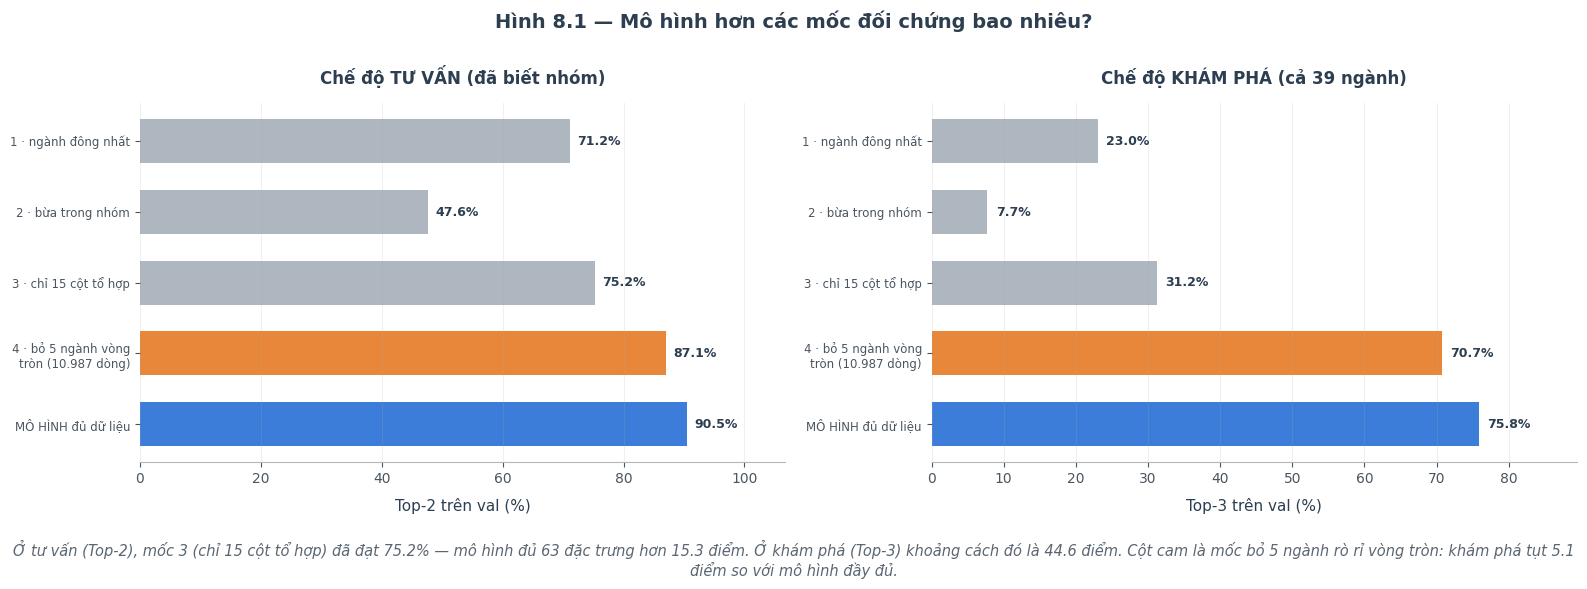

In [5]:
# ═══════════ HÌNH 8.1 — Bốn mốc so với mô hình ═══════════
fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 5.2))
yy = np.arange(len(bang))
mau = [C_XAM] * (len(bang) - 1) + [C_XANH]
mau[3] = C_CAM        # mốc 4 ⭐ tô riêng

for ax, cot, ten_, k_ in [(a1, "tv_val", "Chế độ TƯ VẤN (đã biết nhóm)", K_TU_VAN),
                          (a2, "kp_val", "Chế độ KHÁM PHÁ (cả 39 ngành)", 3)]:
    v = bang[cot].values * 100
    ax.barh(yy, v, color=mau, height=.62)
    ax.set_yticks(yy); ax.set_yticklabels([ngat_dong(m, 22) for m in bang.moc], fontsize=8.5)
    ax.set_xlabel(f"Top-{k_} trên val (%)"); ax.grid(axis="y", alpha=0)
    ax.set_title(ten_, fontsize=12)
    ax.invert_yaxis()
    for i, x_ in enumerate(v):
        ax.text(x_ + 1.2, i, f"{x_:.1f}%", va="center", fontsize=9, fontweight="bold")
    ax.set_xlim(0, max(v) * 1.18)

fig.suptitle("Hình 8.1 — Mô hình hơn các mốc đối chứng bao nhiêu?",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_8_1_bon_moc.png",
    f"Ở tư vấn (Top-{K_TU_VAN}), mốc 3 (chỉ 15 cột tổ hợp) đã đạt {m3.tv_val:.1%} — mô "
    f"hình đủ 63 đặc trưng hơn {(mh_r.tv_val-m3.tv_val)*100:.1f} điểm. Ở khám phá "
    f"(Top-3) khoảng cách đó là "
    f"{(mh_r.kp_val-m3.kp_val)*100:.1f} điểm. Cột cam là mốc bỏ 5 ngành rò rỉ vòng tròn: "
    f"khám phá tụt {(mh_r.kp_val-m4.kp_val)*100:.1f} điểm so với mô hình đầy đủ.")
plt.show()

   💾 hinh_8_2_nho_vet.png


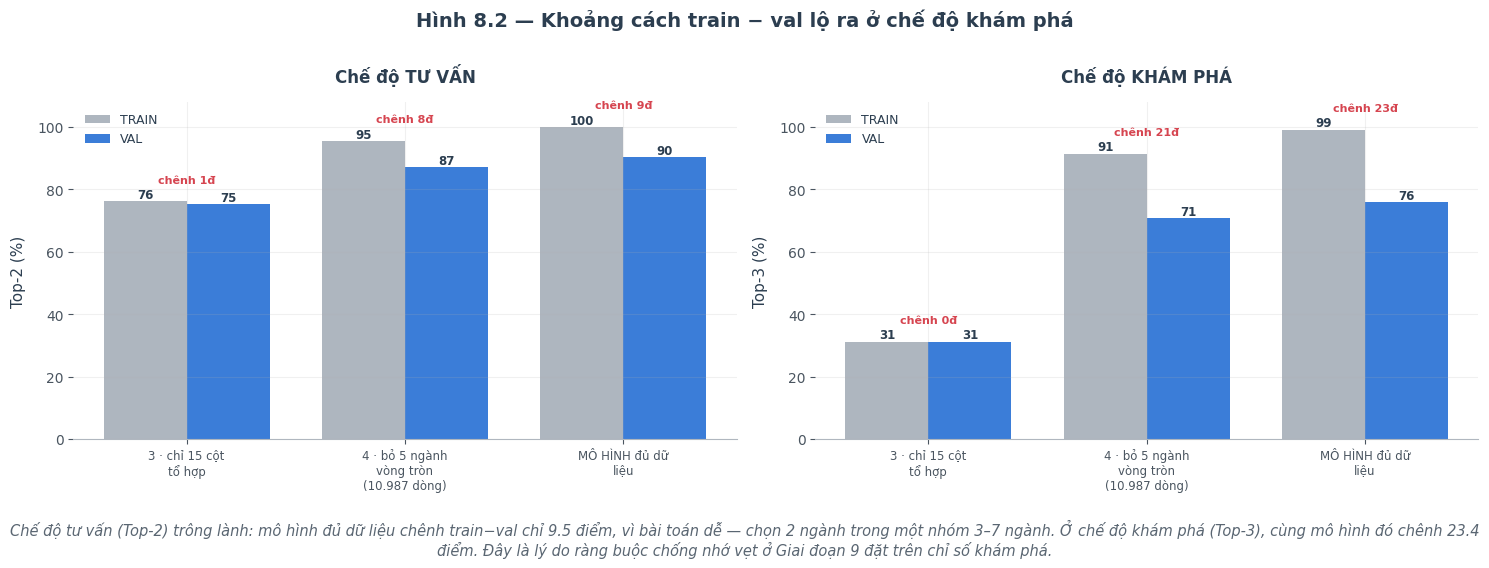

In [6]:
# ═══════════ HÌNH 8.2 — Nhớ vẹt: train so với val ═══════════
co = bang.dropna(subset=["tv_train"])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(co)); w_ = .38

for ax, c_tr, c_va, ten_, k_ in [(a1, "tv_train", "tv_val", "Chế độ TƯ VẤN", K_TU_VAN),
                                 (a2, "kp_train", "kp_val", "Chế độ KHÁM PHÁ", 3)]:
    ax.bar(x - w_/2, co[c_tr] * 100, w_, color=C_XAM, label="TRAIN")
    ax.bar(x + w_/2, co[c_va] * 100, w_, color=C_XANH, label="VAL")
    ax.set_xticks(x); ax.set_xticklabels([ngat_dong(m, 15) for m in co.moc], fontsize=8.5)
    ax.set_ylabel(f"Top-{k_} (%)"); ax.legend(fontsize=9); ax.set_ylim(0, 108)
    ax.set_title(ten_, fontsize=12)
    for i, (a_, b_) in enumerate(zip(co[c_tr] * 100, co[c_va] * 100)):
        ax.text(i - w_/2, a_ + 1, f"{a_:.0f}", ha="center", fontsize=8.5, fontweight="bold")
        ax.text(i + w_/2, b_ + 1, f"{b_:.0f}", ha="center", fontsize=8.5, fontweight="bold")
        ax.text(i, max(a_, b_) + 6, f"chênh {a_-b_:.0f}đ", ha="center", fontsize=8,
                color=C_THAT, fontweight="bold")

fig.suptitle("Hình 8.2 — Khoảng cách train − val lộ ra ở chế độ khám phá",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_8_2_nho_vet.png",
    f"Chế độ tư vấn (Top-{K_TU_VAN}) trông lành: mô hình đủ dữ liệu chênh train−val chỉ "
    f"{(mh_r.tv_train-mh_r.tv_val)*100:.1f} điểm, vì bài toán dễ — chọn {K_TU_VAN} "
    f"ngành trong một nhóm 3–7 ngành. Ở chế độ khám phá (Top-3), cùng mô hình đó chênh "
    f"{(mh_r.kp_train-mh_r.kp_val)*100:.1f} điểm. Đây là lý do ràng buộc chống nhớ vẹt ở "
    f"Giai đoạn 9 đặt trên chỉ số khám phá.")
plt.show()

In [7]:
(OUT / "moc_chuan.json").write_text(json.dumps({
    "n_train": int(len(train)), "n_val": int(len(val)),
    "k": {"tu_van": K_TU_VAN, "kham_pha": 3},
    "ghi_chu": "HƯỚNG 2 — 676 phiếu khảo sát niêm phong từ GĐ 6, không có trong "
               "bảng huấn luyện. sample_weight = 1.0 cho mọi dòng.",
    "moc": {r.moc: {k: (None if np.isnan(getattr(r, k)) else round(getattr(r, k), 4))
                    for k in ("tv_val", "kp_val", "tv_train", "kp_train")}
            for r in bang.itertuples()},
    "phan_do_5_nganh_vong_tron": {"tv": round(float(mh_r.tv_val - m4.tv_val), 4),
                            "kp": round(float(mh_r.kp_val - m4.kp_val), 4)},
    "dong_gop_48_dac_trung": {"tv": round(float(mh_r.tv_val - m3.tv_val), 4),
                              "kp": round(float(mh_r.kp_val - m3.kp_val), 4)},
    "gap_train_val": {"tv": round(float(mh_r.tv_train - mh_r.tv_val), 4),
                      "kp": round(float(mh_r.kp_train - mh_r.kp_val), 4)},
    "chi_so_lop_khampha_val": {k: (None if np.isnan(v) else round(v, 4))
                               for k, v in cs.items()},
}, ensure_ascii=False, indent=2), encoding="utf-8")

tom_tat("GIAI ĐOẠN 8 — BỐN MỐC ĐỐI CHỨNG", [
    f"Đo trên val            {len(val):,} dòng · mọi dòng trọng số 1.0",
    "",
    f"{'Mốc':<34}{'tv@' + str(K_TU_VAN):>10}{'kp@3':>11}",
] + [f"   {r.moc:<31}{r.tv_val:>10.1%}{r.kp_val:>11.1%}" for r in bang.itertuples()] + [
    "",
    f"Hơn bừa trong nhóm     tv {(mh_r.tv_val-m2.tv_val)*100:+.1f}đ"
    f"   kp {(mh_r.kp_val-m2.kp_val)*100:+.1f}đ",
    f"Hơn 'chỉ tổ hợp'       tv {(mh_r.tv_val-m3.tv_val)*100:+.1f}đ"
    f"   kp {(mh_r.kp_val-m3.kp_val)*100:+.1f}đ",
    f"Nhờ 5 ngành vòng tròn ⭐  tv {(mh_r.tv_val-m4.tv_val)*100:+.1f}đ"
    f"   kp {(mh_r.kp_val-m4.kp_val)*100:+.1f}đ",
    "",
    "CHỈ SỐ PHÂN LOẠI (khám phá, val):",
    f"   Top-1               {cs['acc_top1']:.1%}",
    f"   macro-F1            {cs['f1_macro']:.3f}",
    f"   weighted-F1         {cs['f1_weighted']:.3f}",
    f"   AUC OvR             {cs['auc_ovr']:.3f}   (≠ AUC Giai đoạn 5)",
    "",
    f"Chênh train−val        tv {(mh_r.tv_train-mh_r.tv_val)*100:.1f}đ"
    f"   kp {(mh_r.kp_train-mh_r.kp_val)*100:.1f}đ",
    "→ Giai đoạn 9 ràng buộc trên chỉ số KHÁM PHÁ",
])
print(f"\n✅ moc_chuan.json · bang_moc.csv · chi_so_lop.csv · 2 hình  →  {OUT}")

╔════════════════════════════════════════════════════════════════════════════╗
║                      GIAI ĐOẠN 8 — BỐN MỐC ĐỐI CHỨNG                       ║
╠════════════════════════════════════════════════════════════════════════════╣
║ Đo trên val            2,444 dòng · mọi dòng trọng số 1.0                  ║
║                                                                            ║
║ Mốc                                     tv@2       kp@3                    ║
║    1 · ngành đông nhất                 71.2%      23.0%                    ║
║    2 · bừa trong nhóm                  47.6%       7.7%                    ║
║    3 · chỉ 15 cột tổ hợp               75.2%      31.2%                    ║
║    4 · bỏ 5 ngành vòng tròn (10.987 dòng)     87.1%      70.7%             ║
║    MÔ HÌNH đủ dữ liệu                  90.5%      75.8%                    ║
║                                                                            ║
║ Hơn bừa trong nhóm     tv +42.8đ   kp +68.1đ      